In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Input,Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam,SGD
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

2026-02-01 11:50:25.883817: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-01 11:50:25.916012: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-01 11:50:26.755795: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


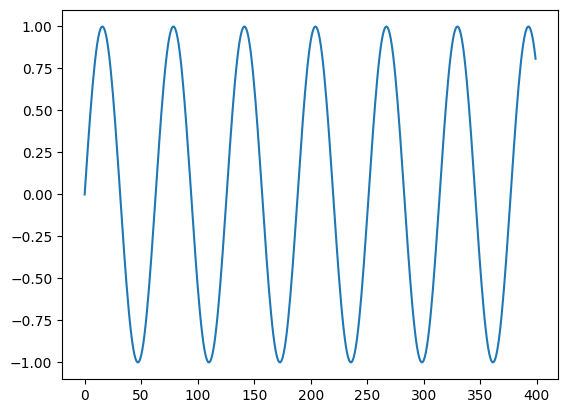

In [2]:
series=np.sin(0.1*np.arange(400))
plt.plot(series)
plt.show()

In [3]:
T=10
X=[]
Y=[]
for t in range(len(series)-T):
    x=series[t:t+T]
    y=series[t+T]
    X.append(x)
    Y.append(y)
X=np.array(X).reshape(-1,T)
Y=np.array(Y)
N=len(X)
print(X.shape,Y.shape)

(390, 10) (390,)


In [4]:
i=Input(shape=(T,))
x=Dense(1)(i)
model=Model(i,x)
model.compile(loss='mse',optimizer=Adam(learning_rate=0.1))
r=model.fit(
    X[:-N//2],Y[:-N//2],epochs=80,validation_data=(X[-N//2:],Y[-N//2:])
    )

I0000 00:00:1769928627.892178  889769 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3822 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


Epoch 1/80
1/7 ━━━━━━━━━━━━━━━━━━━━ 1s 323ms/step - loss: 2.0870

2026-02-01 11:50:28.521287: I external/local_xla/xla/service/service.cc:163] XLA service 0x741ed40054f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-01 11:50:28.521306: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 SUPER, Compute Capability 7.5
2026-02-01 11:50:28.532758: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-01 11:50:28.556018: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801
I0000 00:00:1769928628.653344  889964 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.6812 - val_loss: 0.3937
Epoch 2/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1659 - val_loss: 0.2294
Epoch 3/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0827 - val_loss: 0.1710
Epoch 4/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0841 - val_loss: 0.0376
Epoch 5/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0440 - val_loss: 0.0068
Epoch 6/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0176 - val_loss: 0.0022
Epoch 7/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0084 - val_loss: 9.8139e-04
Epoch 8/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0049 - val_loss: 0.0019
Epoch 9/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 10/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.7863e-04 - val_loss: 7.6544e-04
Epoch 11/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.4447e-04 - val_loss: 3.0176e-04
Epoch 12/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.7965e-04 - val_loss: 1.4013

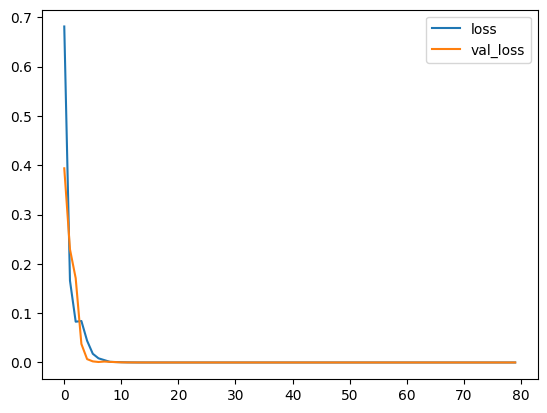

In [5]:
plt.plot(r.history['loss'],label='loss')
plt.plot(r.history['val_loss'],label='val_loss')
plt.legend()

In [ ]:
validation_target=Y[-N//2:]
validation_predictions=[]
i=-N//2
while len(validation_predictions)<len(validation_target):
    p=model.predict(X[i].reshape(1,-1))[0,0]
    i+=1
    validation_predictions.append(p)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━

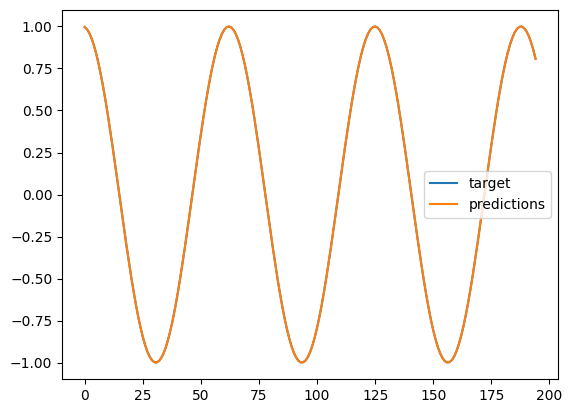

In [7]:
plt.plot(validation_target,label='target')
plt.plot(validation_predictions,label='predictions')
plt.legend()

In [8]:
validation_target=Y[-N//2:]
validation_predictions=[]
last_x=X[-N//2]

while len(validation_predictions)<len(validation_target):
    p=model.predict(last_x.reshape(1,-1))[0,0]
    validation_predictions.append(p)
    last_x=np.roll(last_x,-1)
    last_x[-1]=p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━

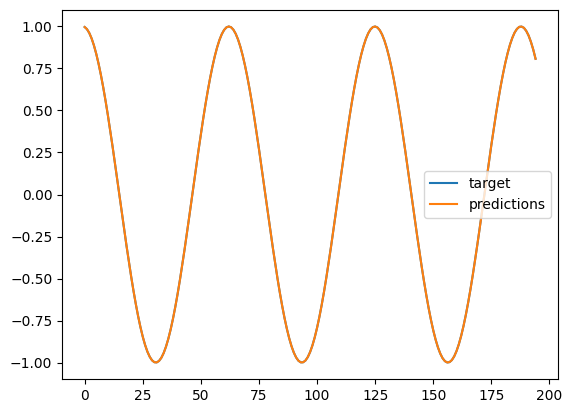

In [9]:
plt.plot(validation_target,label='target')
plt.plot(validation_predictions,label='predictions')
plt.legend()

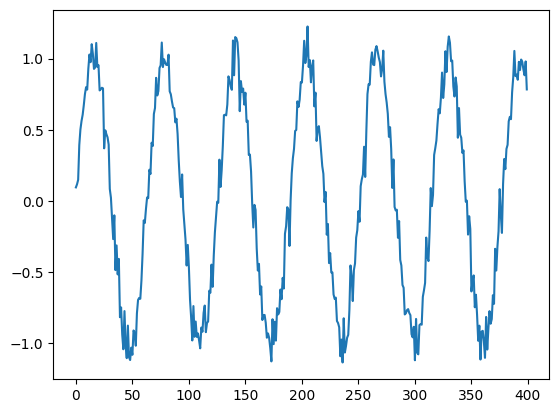

In [10]:
series=np.sin(0.1*np.arange(400))+np.random.randn(400)*0.1
plt.plot(series)
plt.show()

In [11]:
T=10
X=[]
Y=[]
for t in range(len(series)-T):
    x=series[t:t+T]
    y=series[t+T]
    X.append(x)
    Y.append(y)
X=np.array(X).reshape(-1,T)
Y=np.array(Y)
N=len(X)
print(X.shape,Y.shape)

(390, 10) (390,)


In [12]:
i=Input(shape=(T,))
x=Dense(1)(i)
model=Model(i,x)
model.compile(loss='mse',optimizer=Adam(learning_rate=0.1))
r=model.fit(
    X[:-N//2],Y[:-N//2],epochs=80,validation_data=(X[-N//2:],Y[-N//2:])
    )

Epoch 1/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.5335 - val_loss: 0.0851
Epoch 2/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1826 - val_loss: 0.0808
Epoch 3/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1181 - val_loss: 0.1556
Epoch 4/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0822 - val_loss: 0.0944
Epoch 5/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0584 - val_loss: 0.0697
Epoch 6/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0485 - val_loss: 0.0407
Epoch 7/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0375 - val_loss: 0.0299
Epoch 8/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0293 - val_loss: 0.0242
Epoch 9/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0274 - val_loss: 0.0223
Epoch 10/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0247 - val_loss: 0.0209
Epoch 11/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0244 - val_loss: 0.0240
Epoch 12/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0314 - val_loss: 0.0231
Epoch 13/80


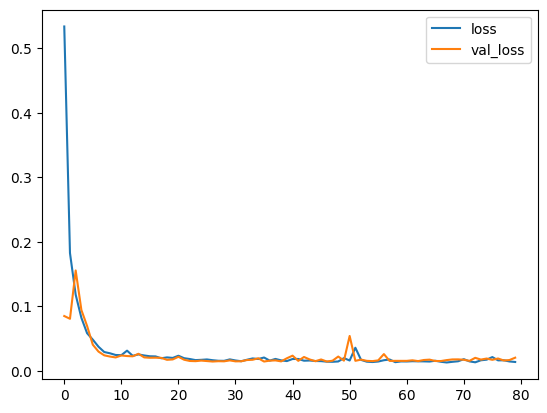

In [13]:
plt.plot(r.history['loss'],label='loss')
plt.plot(r.history['val_loss'],label='val_loss')
plt.legend()

In [ ]:
validation_target=Y[-N//2:]
validation_predictions=[]
i=-N//2
while len(validation_predictions)<len(validation_target):
    p=model.predict(X[i].reshape(1,-1))[0,0]
    i+=1
    validation_predictions.append(p)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

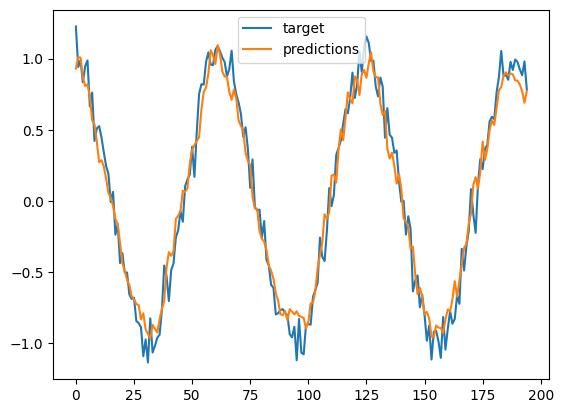

In [15]:
plt.plot(validation_target,label='target')
plt.plot(validation_predictions,label='predictions')
plt.legend()

In [16]:
validation_target=Y[-N//2:]
validation_predictions=[]
last_x=X[-N//2]

while len(validation_predictions)<len(validation_target):
    p=model.predict(last_x.reshape(1,-1))[0,0]
    validation_predictions.append(p)
    last_x=np.roll(last_x,-1)
    last_x[-1]=p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

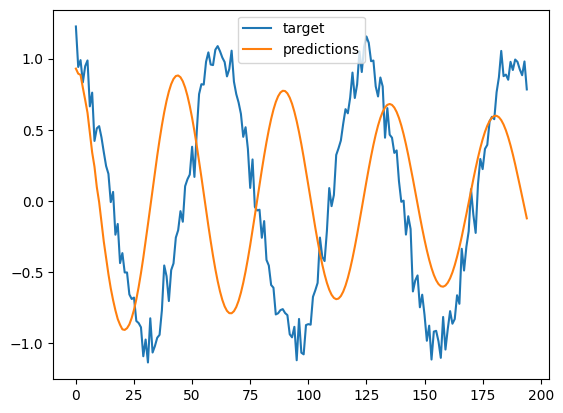

In [17]:
plt.plot(validation_target,label='target')
plt.plot(validation_predictions,label='predictions')
plt.legend()